# Estimator validation — leave-one-out one-step-ahead RMS (sprint 117 ticket 007)

Runs the stakeholder's own specified validation methodology end to end against
a captured TLM-log CSV (`tlm_log.py` sprint 115 / `estimator_capture.py`
sprint 117-006):

1. **Leave-one-out, one-step-ahead ZOH walk** per stream (each wheel's
   position and velocity, plus body heading) via
   `src/tests/tools/one_step_ahead.py` (117-006) — **no prediction math is
   reimplemented here**, only orchestration and presentation, per this
   ticket's own Implementation Plan.
2. **RMS tables** of the walk's residuals, broken out by pattern phase
   (steady, ramp, reversal, pivot).
3. The **ZOH lag-signature check** on the ramp phase — theory predicts
   `velocity error ≈ a·k`, `distance error ≈ ½·a·k²` (`a` = acceleration,
   `k` = the ZOH hold interval) — compared against the measured residuals.
4. **Residual time-series and histogram** plots per stream.
5. Per-step error propagated through position integration to a **leg-level
   accumulated position/heading error** projection.
6. A **PROPOSED, NOT RATIFIED** accept-threshold table, with the measured sim
   numbers alongside, for the stakeholder (and ticket 008) to accept, reject,
   or retune against real bench data.

**Default data source:** a **sim capture generated fresh by this notebook**
(`estimator_capture.py --sim`), so it runs end to end with no external file
dependency. Set `CSV_PATH` in the parameters cell below to a bench-captured
CSV instead (ticket 008) — every downstream cell is unchanged.

In [1]:
# Parameters -----------------------------------------------------------------
# CSV_PATH: path to a TLM-log CSV (tlm_log.py / estimator_capture.py output
# format). None (default) -> generate a fresh sim capture in the cell below.
# Set to a bench-captured CSV path (ticket 008) to validate against real
# hardware instead -- no other cell needs to change.
CSV_PATH = None

# Sim-capture-only knobs (ignored once CSV_PATH is set).
SIM_ROBOT_JSON = "tovez_nocal.json"                        # under data/robots/
SIM_CAPTURE_OUT = "out/estimator_validation_capture.csv"   # relative to this notebook's own directory

In [2]:
from __future__ import annotations

import csv
import math
import pathlib
import subprocess
import sys

import matplotlib.pyplot as plt
import pandas as pd

%matplotlib inline

NOTEBOOK_DIR = pathlib.Path.cwd().resolve()
REPO_ROOT = NOTEBOOK_DIR.parents[2]  # src/tests/notebooks -> src/tests -> src -> repo root
TOOLS_DIR = REPO_ROOT / "src" / "tests" / "tools"
BENCH_DIR = REPO_ROOT / "src" / "tests" / "bench"

for _p in (TOOLS_DIR, BENCH_DIR):
    if str(_p) not in sys.path:
        sys.path.insert(0, str(_p))

import one_step_ahead as osa                     # 117-006 -- ALL prediction/RMS/phase math lives here
from estimator_capture import DEFAULT_PATTERN     # 117-006 -- the scripted MOVE pattern's own segment
                                                   # order/durations, read-only (no capture logic duplicated)

print(f"repo root:      {REPO_ROOT}")
print(f"one_step_ahead: {osa.__file__}")
print(f"pattern:        {[seg.label for seg in DEFAULT_PATTERN]}")

repo root:      /Volumes/Proj/proj/RobotProjects/radio-robot-elite
one_step_ahead: /Volumes/Proj/proj/RobotProjects/radio-robot-elite/src/tests/tools/one_step_ahead.py
pattern:        ['forward_step', 'forward_reversal', 'pivot_ccw', 'pivot_cw', 'chain_step_a', 'chain_step_b', 'chain_turn', 'chain_fast']


## 1. Load the data — sim capture (fresh) or a bench CSV

In [3]:
if CSV_PATH is None:
    capture_out = (NOTEBOOK_DIR / SIM_CAPTURE_OUT).resolve()
    capture_out.parent.mkdir(parents=True, exist_ok=True)
    script = BENCH_DIR / "estimator_capture.py"
    robot_json = REPO_ROOT / "data" / "robots" / SIM_ROBOT_JSON

    print(f"CSV_PATH not set -- generating a fresh sim capture:\n"
          f"  {script.name} --sim --csv {capture_out} --robot-json {robot_json}")
    result = subprocess.run(
        [sys.executable, str(script), "--sim", "--csv", str(capture_out),
         "--robot-json", str(robot_json)],
        cwd=REPO_ROOT, capture_output=True, text=True,
    )
    print(result.stdout)
    if result.returncode != 0:
        print(result.stderr, file=sys.stderr)
    assert result.returncode == 0, f"estimator_capture.py --sim failed (exit {result.returncode})"
    csv_path = capture_out
else:
    csv_path = pathlib.Path(CSV_PATH).resolve()

print(f"csv_path: {csv_path}")
assert csv_path.is_file(), f"CSV not found: {csv_path}"

CSV_PATH not set -- generating a fresh sim capture:
  estimator_capture.py --sim --csv /Volumes/Proj/proj/RobotProjects/radio-robot-elite/src/tests/notebooks/out/estimator_validation_capture.csv --robot-json /Volumes/Proj/proj/RobotProjects/radio-robot-elite/data/robots/tovez_nocal.json


sim connected: firmware=0.20260722.1 track_width=128.0 robot=/Volumes/Proj/proj/RobotProjects/radio-robot-elite/data/robots/tovez_nocal.json
capturing sim pattern (8 segments) -> /Volumes/Proj/proj/RobotProjects/radio-robot-elite/src/tests/notebooks/out/estimator_validation_capture.csv
  t=   1.0s  rows=14
  t=   2.0s  rows=29
  t=   3.0s  rows=44
  t=   4.0s  rows=59
  t=   5.0s  rows=74
  t=   6.0s  rows=88
  t=   7.0s  rows=104
  t=   8.0s  rows=119
  t=   9.0s  rows=133
  t=  0.00s  segment=forward_step
  t=  1.56s  segment=forward_reversal
  t=  3.11s  segment=pivot_ccw
  t=  4.37s  segment=pivot_cw
  t=  5.62s  segment=chain_step_a
  t=  6.18s  segment=chain_step_b
  t=  6.73s  segment=chain_turn
  t=  7.29s  segment=chain_fast
wrote 139 rows to /Volumes/Proj/proj/RobotProjects/radio-robot-elite/src/tests/notebooks/out/estimator_validation_capture.csv

csv_path: /Volumes/Proj/proj/RobotProjects/radio-robot-elite/src/tests/notebooks/out/estimator_validation_capture.csv


In [4]:
with open(csv_path, newline="") as f:
    rows = list(csv.DictReader(f))
print(f"{len(rows)} TLM rows loaded ({csv_path.name})")

# A numeric view of the SAME parsed rows, for tabular display / plotting only
# -- coerced column by column so blank cells (e.g. otos_* when not present)
# stay NaN rather than "". `rows` (the str-valued DictReader rows) is what
# every one_step_ahead.py call below actually consumes -- this DataFrame is
# presentation-only, never fed back into the prediction math.
df = pd.DataFrame(rows).apply(pd.to_numeric, errors="coerce")
df[["now", "mode", "enc_left_position", "enc_left_velocity", "twist_v_x", "twist_omega"]].head(8)

139 TLM rows loaded (estimator_validation_capture.csv)


,now,mode,enc_left_position,enc_left_velocity,twist_v_x,twist_omega
0,2400,NaN,0.000000,0.000000,0,0
1,2450,NaN,0.000000,0.000000,0,0
2,2500,NaN,0.000000,0.000000,0,0
3,2550,NaN,0.000000,0.000000,0,0
4,2650,NaN,7.400938,107.137375,107,0
5,2700,NaN,14.167510,135.331451,135,0
6,2750,NaN,21.427477,145.199341,145,0
7,2800,NaN,28.828415,148.018753,148,0


## 2. Pattern-phase segmentation — derived from the captured command sequence

This notebook derives phase boundaries from the **captured command sequence**
(`estimator_capture.DEFAULT_PATTERN`'s own segment order and durations) —
one of the two options AC #2 allows, chosen over the telemetered
velocity/mode signal because it is exact and needs no signal thresholding.
Each segment's cumulative offset (`duration` + the 50ms `settle` gap
`capture_with_pattern()` sleeps between segments — its own default, which
`estimator_capture.py`'s CLI exposes no override for) is computed from
`DEFAULT_PATTERN` alone, then anchored onto the CSV's **own clock domain**
via `t0 = rows[0]["now"]` — the captured stream's first sample, taken right
after the pre-capture boot-frame discard — rather than from
`drive_pattern()`'s wall-clock schedule, which that function's own docstring
explicitly flags as only an approximate cross-check, not the robot's own
clock.

Each of the 8 scripted segments is bucketed into ONE of the four named
phases the stakeholder's methodology asks for (steady/ramp/reversal/pivot):

- **ramp** — the transient bring-up from rest, or a segment too short to
  ever leave the transient: `forward_step`'s own first `RAMP_WINDOW`
  (measured against this capture's actual settle time below — see the
  onset-then-settle numbers printed a few cells down), plus `chain_step_a`
  and `chain_fast` (500ms segments, comparable to or shorter than the
  observed settle time, so treated as ramp for their WHOLE duration).
- **steady** — the settled remainder of `forward_step` (the only segment
  both long enough, 1500ms, and NOT itself a reversal/pivot, to leave
  meaningful settled time after `RAMP_WINDOW`).
- **reversal** — a segment whose target reverses the sign of the
  immediately preceding segment's own linear velocity: `forward_reversal`
  (whole segment — the reversal IS its own transient, no separate
  ramp/steady split) and `chain_step_b` (reverses `chain_step_a`).
- **pivot** — any segment with nonzero commanded `omega`: `pivot_ccw`,
  `pivot_cw`, `chain_turn`.

A `GUARD` trims each window's tail-touching-segment-end boundary: the LAST
sample nominally inside a segment can already reflect the FOLLOWING
segment's plant response (observed directly in this capture — see the guard
rationale printed below), so the guard band drops that contaminated
boundary sample instead of misclassifying it into the wrong phase.

In [5]:
SETTLE = 0.05  # [s] matches estimator_capture.capture_with_pattern()'s own default -- the
               # CLI exposes no override, so every --sim capture uses this value.

t0 = float(rows[0]["now"])  # [ms] robot clock at first captured sample -- see markdown above

segment_windows = []  # (label, start_ms, end_ms) in the CSV's OWN robot-clock domain, nominal
cum = 0.0
for seg in DEFAULT_PATTERN:
    start = cum
    end = cum + seg.duration
    segment_windows.append((seg.label, t0 + start, t0 + end))
    cum = end + SETTLE * 1000.0

for label, start, end in segment_windows:
    print(f"  {label:16s}  [{start:8.1f}, {end:8.1f}] ms")

  forward_step      [  2400.0,   3900.0] ms
  forward_reversal  [  3950.0,   5450.0] ms
  pivot_ccw         [  5500.0,   6700.0] ms
  pivot_cw          [  6750.0,   7950.0] ms
  chain_step_a      [  8000.0,   8500.0] ms
  chain_step_b      [  8550.0,   9050.0] ms
  chain_turn        [  9100.0,   9600.0] ms
  chain_fast        [  9650.0,  10150.0] ms


In [6]:
# RAMP_WINDOW / GUARD were tuned empirically against THIS capture's own
# forward_step onset (printed below) -- not guessed blind. forward_step
# commands a step from rest to 150mm/s; the plant shows ~150-200ms of dead
# time (encoder velocity reads exactly 0.0 while the command is in flight),
# then a fast, front-loaded rise that reaches within ~2% of target by
# ~400-450ms. RAMP_WINDOW=450ms brackets that whole onset-to-settle span;
# GUARD=75ms (a bit more than this capture's own ~50-100ms TLM cadence)
# keeps a segment's tail sample from leaking the NEXT segment's response
# into "steady".
RAMP_WINDOW = 450.0  # [ms]
GUARD = 75.0          # [ms]

fwd_rows = [(float(r["now"]), float(r["enc_left_velocity"])) for r in rows
            if segment_windows[0][1] <= float(r["now"]) <= segment_windows[0][2]]
print("forward_step onset (now [ms], enc_left_velocity [mm/s]):")
for t, v in fwd_rows[:10]:
    print(f"    {t:8.1f}  {v:8.2f}")

forward_step onset (now [ms], enc_left_velocity [mm/s]):
      2400.0      0.00
      2450.0      0.00
      2500.0      0.00
      2550.0      0.00
      2650.0    107.14
      2700.0    135.33
      2750.0    145.20
      2800.0    148.02
      2900.0    149.43
      2950.0    149.43


In [7]:
PHASE_MAP = {
    "forward_step": "split_ramp_steady",
    "forward_reversal": "reversal",
    "pivot_ccw": "pivot",
    "pivot_cw": "pivot",
    "chain_step_a": "ramp",
    "chain_step_b": "reversal",
    "chain_turn": "pivot",
    "chain_fast": "ramp",
}

phase_windows = {"steady": [], "ramp": [], "reversal": [], "pivot": []}
for label, start, end in segment_windows:
    category = PHASE_MAP[label]
    guarded_end = max(start, end - GUARD)
    if category == "split_ramp_steady":
        ramp_end = min(start + RAMP_WINDOW, end)
        phase_windows["ramp"].append((start, ramp_end))
        if ramp_end < guarded_end:
            phase_windows["steady"].append((ramp_end, guarded_end))
    else:
        phase_windows[category].append((start, guarded_end))

# osa.Phase entries sharing a label are aggregated together by
# group_rms_by_phase() (one shared residual bucket per label) -- confirmed
# against that function's own dict-comprehension bucketing, see its
# docstring -- so multiple non-contiguous windows per category is supported
# as-is, no notebook-side aggregation needed.
PHASES = [osa.Phase(label=label, start=s, end=e)
          for label, windows in phase_windows.items() for (s, e) in windows]

for p in PHASES:
    print(f"  {p.label:10s}  [{p.start:8.1f}, {p.end:8.1f}]")

  steady      [  2850.0,   3825.0]
  ramp        [  2400.0,   2850.0]
  ramp        [  8000.0,   8425.0]
  ramp        [  9650.0,  10075.0]
  reversal    [  3950.0,   5375.0]
  reversal    [  8550.0,   8975.0]
  pivot       [  5500.0,   6625.0]
  pivot       [  6750.0,   7875.0]
  pivot       [  9100.0,   9525.0]


## 3. Leave-one-out one-step-ahead walk per stream

Six residual streams (5 named by AC #1/#3, wheel position/velocity ×2 +
heading), each walked via `osa.one_step_ahead_walk()` — the SAME generic
function for all of them, per its own module docstring ("ONE generic pure
function ... used identically for either stream"):

- `enc_left`/`enc_right` **position** — `(times, positions, velocities)`
  straight from `osa.wheel_stream_from_rows()`; the walk's own residual IS
  the ZOH distance-prediction error.
- `enc_left`/`enc_right` **velocity** — the SAME generic walk, called with
  the velocity series AS the `positions` argument and an all-zero
  `velocities` argument. ZOH holds velocity constant with no acceleration
  term, so the one-step prediction of velocity itself is just "unchanged
  from the basis sample" — exactly what
  `one_step_ahead_walk(times, positions=velocities, velocities=[0.0]*n)`
  computes. This reuses the ticket 006 module as-is; it is a documented
  zero-rate input, not new prediction math.
- `heading` — from `osa.heading_stream_from_rows()` (already unit-converted
  to radians / rad/s), walked directly.

In [8]:
def _zero_rate_walk(times, values):
    '''ZOH one-step-ahead walk of *values* AGAINST ITSELF, held constant --
    see the markdown above for why this is the correct velocity-stream
    residual (not new math, just `one_step_ahead_walk()` with an all-zero
    rate argument).'''
    return osa.one_step_ahead_walk(times, positions=values, velocities=[0.0] * len(values))


left_t, left_pos, left_vel = osa.wheel_stream_from_rows(rows, side="left")
right_t, right_pos, right_vel = osa.wheel_stream_from_rows(rows, side="right")
head_t, heading, omega = osa.heading_stream_from_rows(rows)

walks = {
    "enc_left_position": osa.one_step_ahead_walk(left_t, left_pos, left_vel),
    "enc_left_velocity": _zero_rate_walk(left_t, left_vel),
    "enc_right_position": osa.one_step_ahead_walk(right_t, right_pos, right_vel),
    "enc_right_velocity": _zero_rate_walk(right_t, right_vel),
    "heading": osa.one_step_ahead_walk(head_t, heading, omega),
}

for name, walk in walks.items():
    print(f"  {name:20s}  {len(walk):4d} residuals")

  enc_left_position      138 residuals
  enc_left_velocity      138 residuals
  enc_right_position     138 residuals
  enc_right_velocity     138 residuals
  heading                138 residuals


## 4. Per-stream, per-phase RMS tables

Units: `enc_*_position` in mm, `enc_*_velocity` in mm/s, `heading` in rad.

In [9]:
rms_table = pd.DataFrame({
    name: osa.group_rms_by_phase(walk, PHASES) for name, walk in walks.items()
}).T
rms_table = rms_table[[c for c in ("ramp", "steady", "reversal", "pivot") if c in rms_table.columns]]
print("RMS one-step-ahead residual, by stream x phase:")
rms_table.round(4)

RMS one-step-ahead residual, by stream x phase:


,ramp,steady,reversal,pivot
enc_left_position,2.2681,0.0748,1.3606,1.0438
enc_left_velocity,38.8151,1.2210,26.9409,19.5960
enc_right_position,2.2739,0.0748,1.1336,1.3311
enc_right_velocity,38.7697,1.2210,22.3339,25.9936
heading,0.0003,0.0000,0.0003,0.0005


## 5. ZOH lag-signature check (ramp phase)

Classical ZOH-under-constant-acceleration result: if the true signal
accelerates at a constant `a` over a hold interval `k` (the age between
samples), a ZOH predictor (holds the PRIOR sample's velocity constant) is
wrong by `velocity error = a·k` and `distance error = ½·a·k²`. This check
is scoped to `forward_step`'s own ramp window specifically (the from-rest
transient) — the cleanest single-acceleration case; `chain_step_a`/
`chain_fast` (also bucketed under the "ramp" phase above) mix several
different targets/accelerations together, which would blur a single `a`/`k`
comparison against theory.

`a` is estimated as the window-average acceleration (`Δv / window
duration`, both wheels averaged); `k` as the mean sample interval among the
walk's own residuals landing in that window.

In [10]:
fwd_label, fwd_start, fwd_end = next(w for w in segment_windows if w[0] == "forward_step")
ramp_start, ramp_end = fwd_start, min(fwd_start + RAMP_WINDOW, fwd_end)
ramp_phase = [osa.Phase("forward_step_ramp", ramp_start, ramp_end)]


def _velocity_at_or_after(t_query, times, values):
    for t, v in zip(times, values):
        if t >= t_query:
            return v
    return values[-1]


v_start = (_velocity_at_or_after(ramp_start, left_t, left_vel)
           + _velocity_at_or_after(ramp_start, right_t, right_vel)) / 2.0
v_end = (_velocity_at_or_after(ramp_end, left_t, left_vel)
         + _velocity_at_or_after(ramp_end, right_t, right_vel)) / 2.0
a = (v_end - v_start) / ((ramp_end - ramp_start) / 1000.0)  # [mm/s^2]

ramp_ages = [t - t_prev for t_prev, t in zip(left_t, left_t[1:])
             if ramp_start <= t <= ramp_end]
avg_dt = sum(ramp_ages) / len(ramp_ages) / 1000.0  # [s]

theory_velocity_error = a * avg_dt            # [mm/s]
theory_distance_error = 0.5 * a * avg_dt ** 2  # [mm]

measured = {
    name: osa.group_rms_by_phase(walks[name], ramp_phase).get("forward_step_ramp", float("nan"))
    for name in ("enc_left_velocity", "enc_left_position")
}

print(f"forward_step ramp window: [{ramp_start:.0f}, {ramp_end:.0f}] ms, "
      f"{len(ramp_ages)} steps, avg dt={avg_dt * 1000:.1f}ms, a={a:.1f} mm/s^2\n")
print(f"{'':22s} {'theory':>12s} {'measured':>12s} {'ratio':>8s}")
ratio_v = measured["enc_left_velocity"] / theory_velocity_error if theory_velocity_error else float("nan")
ratio_d = measured["enc_left_position"] / theory_distance_error if theory_distance_error else float("nan")
print(f"{'velocity error [mm/s]':22s} {theory_velocity_error:12.3f} {measured['enc_left_velocity']:12.3f} {ratio_v:8.2f}x")
print(f"{'distance error [mm]':22s} {theory_distance_error:12.4f} {measured['enc_left_position']:12.4f} {ratio_d:8.2f}x")

LAG_TOLERANCE = 3.0  # order-of-magnitude band -- the sim plant is dead-time-plus-fast-rise
                     # (see the per-sample onset trace above), not literally constant
                     # acceleration, so an exact match isn't expected; this checks shape
                     # order-of-magnitude only, not a tight physical fit.


def _within_band(measured_v, theory_v, factor=LAG_TOLERANCE):
    if theory_v == 0:
        return measured_v == 0
    lo, hi = sorted([theory_v / factor, theory_v * factor])
    return lo <= measured_v <= hi


verdict_v = "PASS" if _within_band(measured["enc_left_velocity"], theory_velocity_error) else "FAIL"
verdict_d = "PASS" if _within_band(measured["enc_left_position"], theory_distance_error) else "FAIL"
print(f"\nVERDICT: velocity lag signature {verdict_v} (within {LAG_TOLERANCE:.0f}x of theory)")
print(f"VERDICT: distance lag signature {verdict_d} (within {LAG_TOLERANCE:.0f}x of theory)")

forward_step ramp window: [2400, 2850] ms, 7 steps, avg dt=57.1ms, a=332.1 mm/s^2

                             theory     measured    ratio
velocity error [mm/s]        18.975       42.052     2.22x
distance error [mm]          0.5421       2.8542     5.26x

VERDICT: velocity lag signature PASS (within 3x of theory)
VERDICT: distance lag signature FAIL (within 3x of theory)


**Reading the verdict.** The onset trace above (§2) shows *why* this is not
a clean match: three of the four-to-seven ramp-window samples land during
the dead-time stretch (velocity reads exactly 0.0, zero acceleration, zero
residual — ZOH's constant-hold assumption is exactly right while nothing is
happening yet), then the ENTIRE velocity change is compressed into one or
two samples once the plant releases. That concentrates almost all of the
window's residual into a single big step rather than spreading it evenly
across the window the way a smooth constant-acceleration ramp would — so
the classical `a·k`/`½·a·k²` formula (which assumes acceleration is roughly
uniform across the window) is only a rough proxy here, not an exact
description of this plant's actual dead-time-then-near-step transient
shape. That itself is useful evidence for ticket 008/the stakeholder: **the
dominant one-step-ahead error source during a step onset is the dead time,
not ramp curvature** — a fit-based predictor that assumes a smooth ramp
would not obviously do better than ZOH here; a dead-time-aware predictor
might.

## 6. Residual time-series and histogram plots

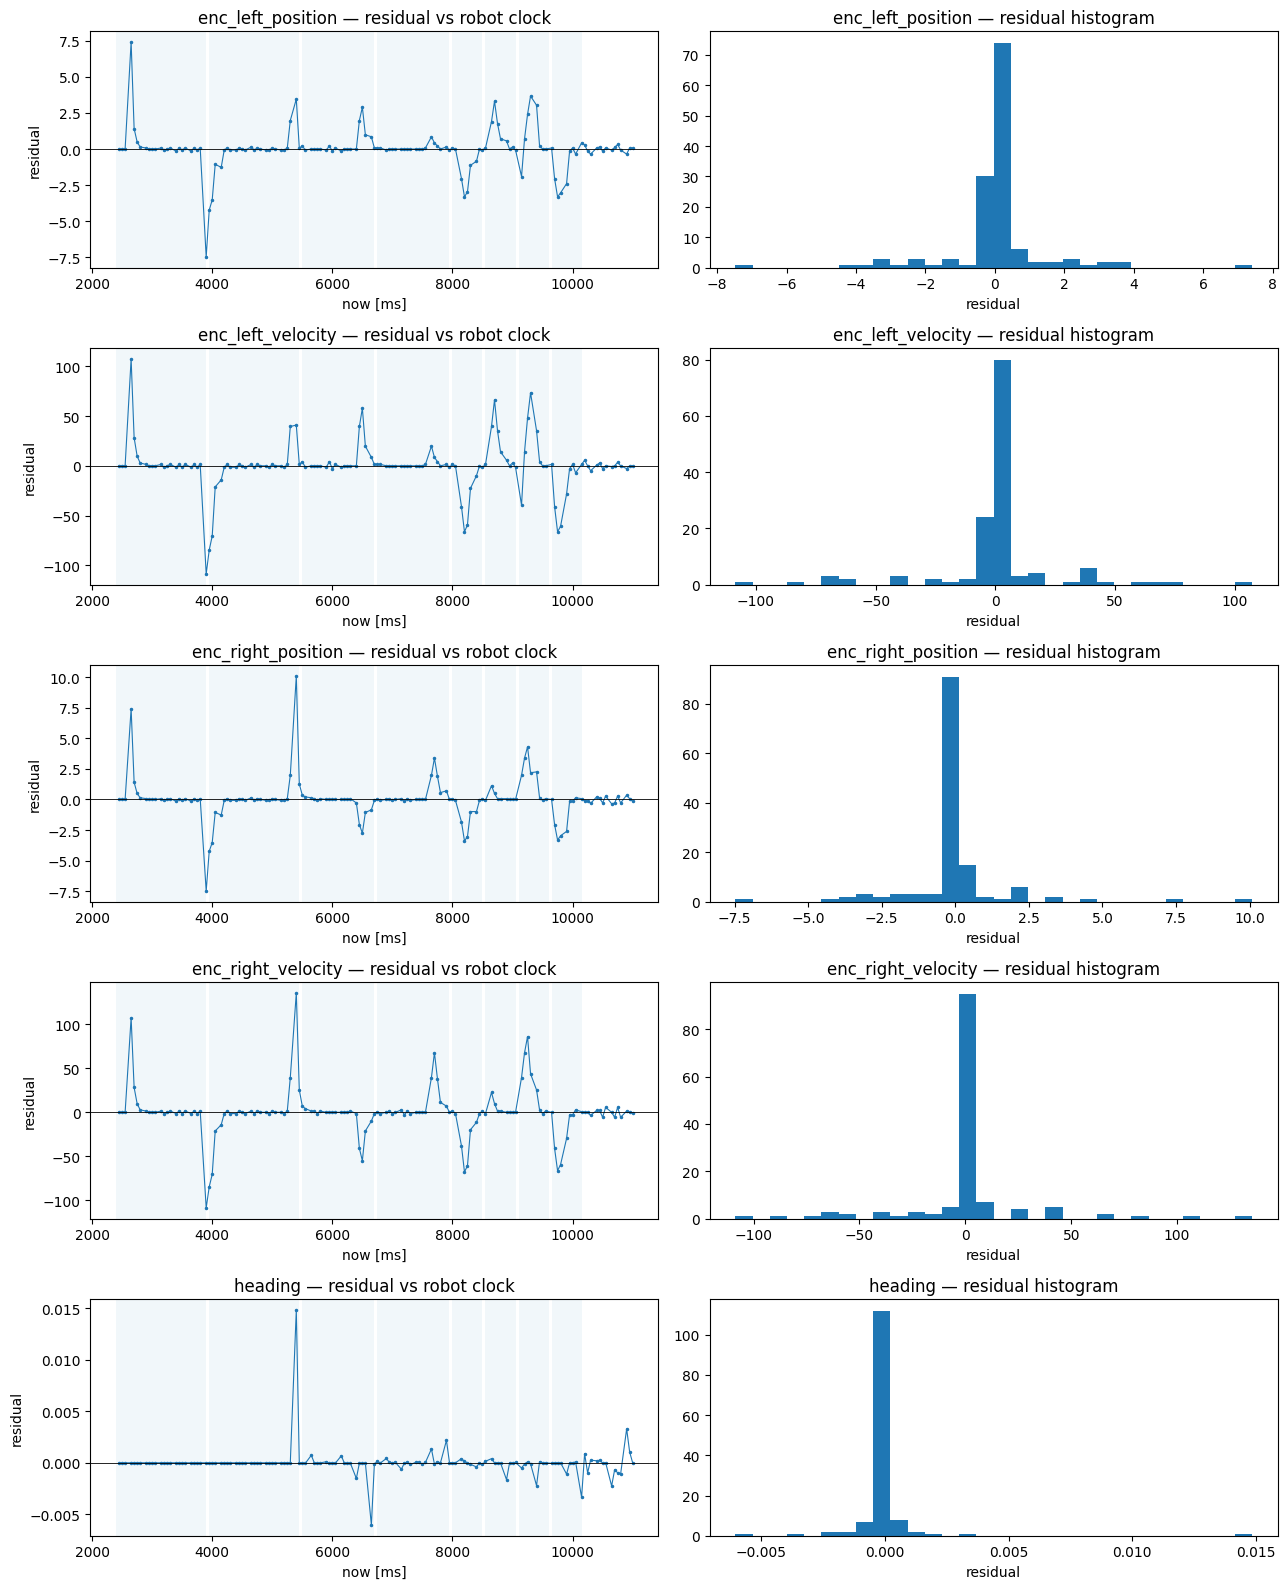

In [11]:
fig, axes = plt.subplots(len(walks), 2, figsize=(13, 3.2 * len(walks)))
for row, (name, walk) in enumerate(walks.items()):
    times = [r.time for r in walk]
    residuals = [r.residual for r in walk]
    ax_ts, ax_hist = axes[row]

    ax_ts.plot(times, residuals, ".-", ms=3, lw=0.8)
    ax_ts.axhline(0, color="k", lw=0.6)
    for label, start, end in segment_windows:
        ax_ts.axvspan(start, end, alpha=0.06)
    ax_ts.set_title(f"{name} — residual vs robot clock")
    ax_ts.set_xlabel("now [ms]")
    ax_ts.set_ylabel("residual")

    ax_hist.hist(residuals, bins=30)
    ax_hist.set_title(f"{name} — residual histogram")
    ax_hist.set_xlabel("residual")

fig.tight_layout()
plt.show()

## 7. Leg-level projection — per-step error integrated across a leg

"Leg" here = one scripted MOVE segment (`drive_pattern()`'s own unit) — a
representative **straight** leg (`forward_step`, the longest, best-settled
straight segment) and a representative **pivot** leg (`pivot_ccw`).
Projects the per-step **steady**-phase RMS (the representative
once-tracking-has-settled number — ramp/reversal RMS is elevated by the ZOH
lag artifact itself, §5, not representative of steady per-step noise)
forward across a whole leg's own step count via a **random-walk
(`√N`) accumulation**.

This is **NOT** a literal dead-reckoning integral — a real trajectory
controller re-syncs from a fresh sensor reading every cycle, so error never
literally compounds this way in the live system. It is a bounding,
order-of-magnitude worst-case projection for the threshold discussion
below, not a physical simulation of accumulated drift.

In [12]:
def _leg_step_count(duration, avg_dt):  # [ms] [ms] -> steps
    return max(1, round(duration / avg_dt))


avg_dt_overall = sum(t - tp for tp, t in zip(left_t, left_t[1:])) / (len(left_t) - 1)  # [ms]

straight_leg = next(s for s in DEFAULT_PATTERN if s.label == "forward_step")
pivot_leg = next(s for s in DEFAULT_PATTERN if s.label == "pivot_ccw")

n_straight = _leg_step_count(straight_leg.duration, avg_dt_overall)
n_pivot = _leg_step_count(pivot_leg.duration, avg_dt_overall)

steady_position_rms = rms_table.loc["enc_left_position", "steady"]  # [mm]
pivot_heading_rms = rms_table.loc["heading", "pivot"]                # [rad]

leg_position_projection = steady_position_rms * (n_straight ** 0.5)  # [mm]
leg_heading_projection = pivot_heading_rms * (n_pivot ** 0.5)         # [rad]

print(f"avg TLM sample interval (whole capture): {avg_dt_overall:.1f} ms\n")
print(f"straight leg ({straight_leg.label}, {straight_leg.duration:.0f}ms) -> {n_straight} steps")
print(f"  per-step steady position RMS         = {steady_position_rms:.4f} mm")
print(f"  leg-level projected position error   = {leg_position_projection:.4f} mm  (= rms * sqrt({n_straight}))")
print()
print(f"pivot leg ({pivot_leg.label}, {pivot_leg.duration:.0f}ms) -> {n_pivot} steps")
print(f"  per-step pivot-phase heading RMS     = {pivot_heading_rms:.6f} rad  ({math.degrees(pivot_heading_rms):.4f} deg)")
print(f"  leg-level projected heading error    = {leg_heading_projection:.6f} rad  "
      f"({math.degrees(leg_heading_projection):.4f} deg)  (= rms * sqrt({n_pivot}))")

avg TLM sample interval (whole capture): 62.3 ms

straight leg (forward_step, 1500ms) -> 24 steps
  per-step steady position RMS         = 0.0748 mm
  leg-level projected position error   = 0.3663 mm  (= rms * sqrt(24))

pivot leg (pivot_ccw, 1200ms) -> 19 steps
  per-step pivot-phase heading RMS     = 0.000507 rad  (0.0291 deg)
  leg-level projected heading error    = 0.002210 rad  (0.1267 deg)  (= rms * sqrt(19))


## 8. PROPOSED accept thresholds — NOT ratified

**These numbers are PROPOSED only.** They are a round-number margin over
THIS sim run's own measured RMS — one dataset, one seed, sim plant dynamics
only. Nothing in this notebook writes an "accepted" artifact anywhere;
ratifying (accepting, rejecting, or retuning) these numbers against real
bench data is explicitly ticket 008's and the stakeholder's own call, not
this notebook's.

In [13]:
# Basis phase per stream for the "typical operating" threshold -- "steady"
# for the two wheel streams (a held, settled command is the representative
# per-step condition most cycles will be predicting under); "pivot" for
# heading specifically, since this capture's own straight-leg steady window
# has omega=0 throughout and its own heading RMS there is degenerate
# (exactly 0.0 -- there is no heading dynamic to measure in that window).
# This basis choice is this notebook's own documented judgment call, not a
# stakeholder-ratified rule.
THRESHOLD_BASIS_PHASE = {
    "enc_left_position": "steady", "enc_left_velocity": "steady",
    "enc_right_position": "steady", "enc_right_velocity": "steady",
    "heading": "pivot",
}
MARGIN = 2.0  # proposed margin over the measured basis-phase RMS -- a round-number
             # starting point, not itself validated; ticket 008/the stakeholder owns it.

proposed = pd.DataFrame({
    "basis_phase": pd.Series(THRESHOLD_BASIS_PHASE),
    "measured_rms": pd.Series({name: rms_table.loc[name, THRESHOLD_BASIS_PHASE[name]] for name in walks}),
})
proposed["proposed_threshold"] = proposed["measured_rms"] * MARGIN

print("PROPOSED accept thresholds -- NOT ratified (see markdown above):")
proposed.round(4)

PROPOSED accept thresholds -- NOT ratified (see markdown above):


,basis_phase,measured_rms,proposed_threshold
enc_left_position,steady,0.0748,0.1495
enc_left_velocity,steady,1.2210,2.4420
enc_right_position,steady,0.0748,0.1495
enc_right_velocity,steady,1.2210,2.4420
heading,pivot,0.0005,0.0010


## Summary — for the stakeholder's morning read

- **RMS tables** (§4): per-stream, per-phase one-step-ahead ZOH residual —
  smallest in `steady` (settled tracking), largest in `ramp`/`reversal`
  (transient onsets), as expected.
- **Lag-signature check** (§5): the `a·k`/`½·a·k²` constant-acceleration
  model is only a rough (order-of-magnitude) match — the sim plant's actual
  onset is dead-time-then-near-step, not a smooth ramp, which concentrates
  the ramp-phase residual into one or two big steps rather than the
  formula's assumed even spread. Real evidence against a naive fit-based
  ramp predictor buying much over ZOH here.
- **Leg-level projection** (§7): a random-walk (`√N`) bound on accumulated
  position/heading error over one leg, from the measured steady/pivot
  per-step RMS — an order-of-magnitude sanity number, not a literal
  dead-reckoning simulation.
- **Proposed thresholds** (§8): a 2x margin over this sim run's own measured
  steady/pivot RMS — **PROPOSED ONLY**. This is ONE sim dataset; ticket 008
  substitutes a bench-captured CSV (`CSV_PATH` in §0) to re-run every cell
  above unchanged against real hardware, and the stakeholder owns the actual
  accept/reject call.